In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("C:/Users/shard/OneDrive/Desktop/TOPS/ML/UnSupervised/marketing_campaign.csv", sep='\t')

In [7]:
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [11]:
# ===============================
# 1. Load and Clean Dataset
# ===============================

df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Convert Year_Birth → Age
df['Age'] = 2024 - df['Year_Birth']

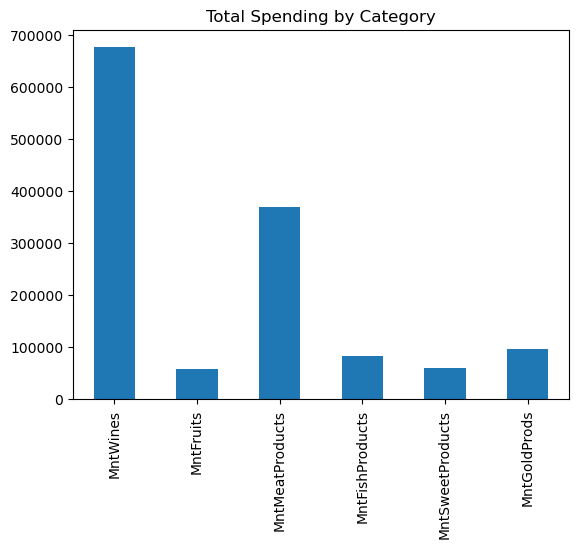

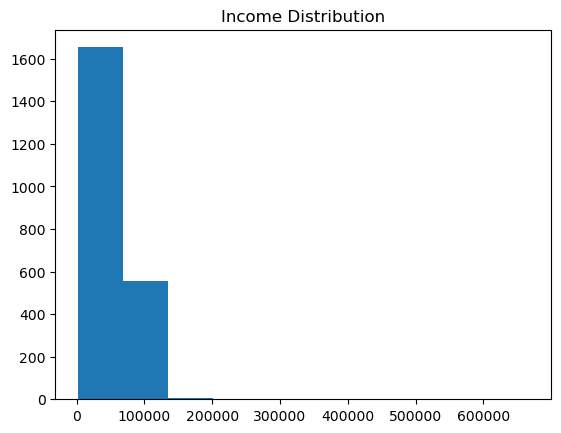

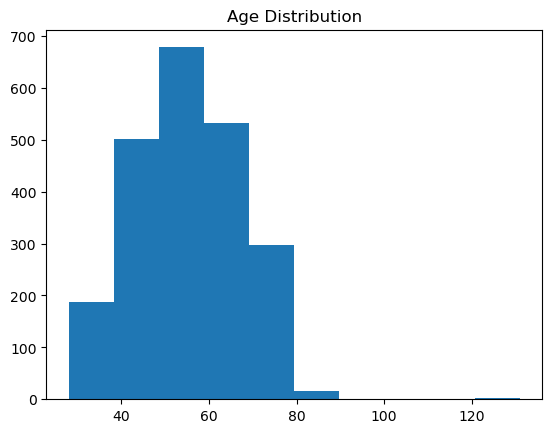

In [10]:
# ===============================
# 2. Visualize Spending Patterns
# ===============================

spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']

# Total spending
df[spending_cols].sum().plot(kind='bar')
plt.title("Total Spending by Category")
plt.show()

# Income distribution
plt.hist(df['Income'])
plt.title("Income Distribution")
plt.show()

# Age distribution
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.show()


In [12]:
# ===============================
# 3. Normalize Numerical Features
# ===============================
from sklearn.preprocessing import StandardScaler

features = ['Income', 'Recency', 'Age'] + spending_cols
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


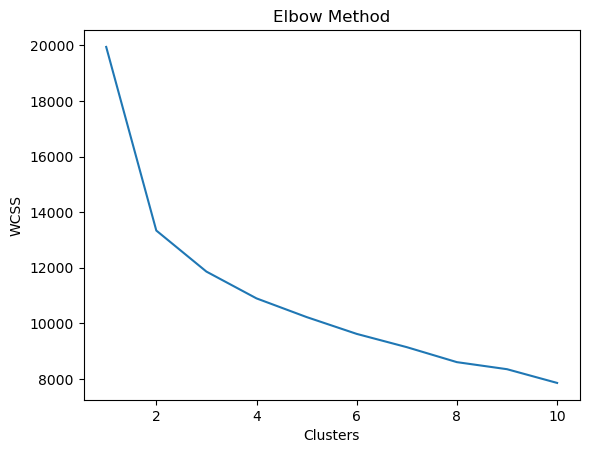

In [14]:
# ===============================
# 4. Elbow Method
# ===============================
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()



In [15]:
# ===============================
# 5. K-Means Clustering
# ===============================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


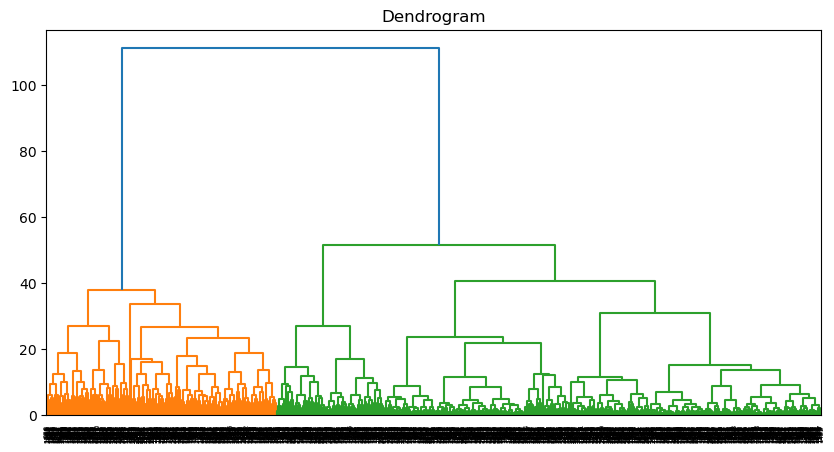

In [16]:
# ===============================
# 6. Hierarchical Clustering
# ===============================
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Dendrogram
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.show()

# Apply Hierarchical
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df['HC_Cluster'] = hc.fit_predict(X_scaled)


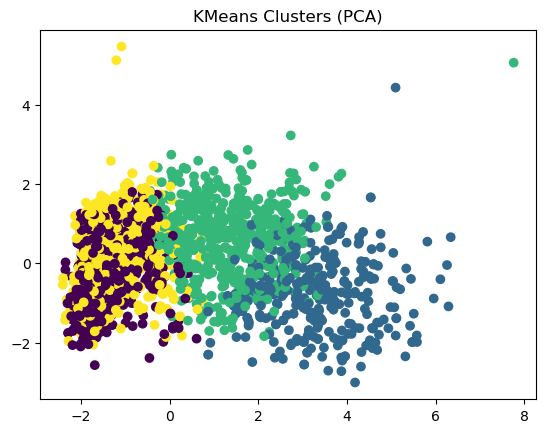

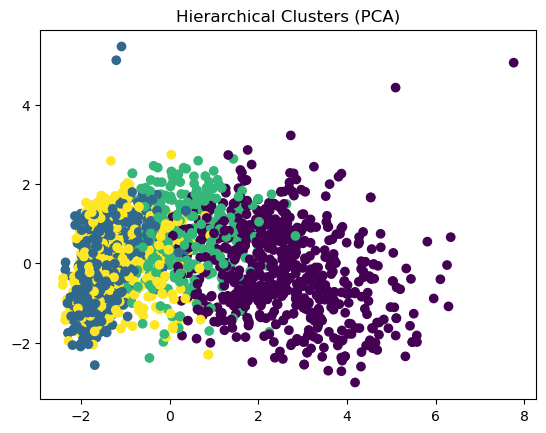

In [17]:
# ===============================
# 7. PCA Visualization
# ===============================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['KMeans_Cluster'])
plt.title("KMeans Clusters (PCA)")
plt.show()

# Hierarchical clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['HC_Cluster'])
plt.title("Hierarchical Clusters (PCA)")
plt.show()

In [18]:
# ===============================
# 8. Cluster Profiling
# ===============================
cluster_profile = df.groupby('KMeans_Cluster')[features].mean()
print("\nCluster Profile:\n")
print(cluster_profile)



Cluster Profile:

                      Income    Recency        Age    MntWines  MntFruits  \
KMeans_Cluster                                                              
0               37642.623512  23.813988  52.520833   95.162202   6.543155   
1               74460.604790  48.185629  53.874251  520.670659  92.092814   
2               71458.584670  50.101604  58.850267  660.966132  33.347594   
3               39331.214176  74.588598  55.431433  103.895223   6.996918   

                MntMeatProducts  MntFishProducts  MntSweetProducts  \
KMeans_Cluster                                                       
0                     35.116071         9.834821          6.028274   
1                    446.365269       130.673653         96.556886   
2                    307.459893        47.862745         33.655971   
3                     38.357473         9.707242          7.263482   

                MntGoldProds  
KMeans_Cluster                
0                  21.066964  
1   

In [19]:
# ===============================
# 9. Dataset with Cluster Labels
# ===============================
print("\nDataset with clusters:\n")
print(df[['KMeans_Cluster','HC_Cluster']].head())


Dataset with clusters:

   KMeans_Cluster  HC_Cluster
0               1           0
1               0           1
2               2           0
3               0           1
4               3           3


In [20]:
# ===============================
# 10. Marketing Strategy
# ===============================
print("\nMarketing Strategy:\n")

print("Cluster 0: High Income & High Spending → Premium customers")
print("Strategy: Offer luxury products, loyalty rewards")

print("\nCluster 1: Low Income & Low Spending → Budget customers")
print("Strategy: Provide discounts, affordable deals")

print("\nCluster 2: Moderate customers")
print("Strategy: Personalized ads, recommendations")

print("\nCluster 3: Low activity (high recency)")
print("Strategy: Re-engagement campaigns, email marketing")


Marketing Strategy:

Cluster 0: High Income & High Spending → Premium customers
Strategy: Offer luxury products, loyalty rewards

Cluster 1: Low Income & Low Spending → Budget customers
Strategy: Provide discounts, affordable deals

Cluster 2: Moderate customers
Strategy: Personalized ads, recommendations

Cluster 3: Low activity (high recency)
Strategy: Re-engagement campaigns, email marketing
